<a href="https://colab.research.google.com/github/susmitsingh01/triton-llm-kernels-lab/blob/main/triton_lab_notebook_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 06: Paged Attention Kernel

Standard attention requires contiguous KV cache — each sequence must have
its KV cache allocated upfront as one contiguous block. This wastes memory
when sequences have variable lengths and prevents efficient batching.

Paged Attention splits the KV cache into fixed-size physical pages allocated
on demand. A page table maps logical token positions to physical memory
locations. The attention kernel reads K and V via this indirection — pages
can be scattered in memory but the kernel sees a logical sequential view.

This notebook implements the page table, memory pool, and paged attention
kernel from scratch in Triton.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_DIR = '/content/drive/MyDrive/triton-llm-kernels-lab'
PLOTS_DIR = os.path.join(BASE_DIR, 'plots', '06_paged_attention')

os.makedirs(PLOTS_DIR, exist_ok=True)

print(f'Base directory : {BASE_DIR}')
print(f'Plots directory: {PLOTS_DIR}')

Mounted at /content/drive
Base directory : /content/drive/MyDrive/triton-llm-kernels-lab
Plots directory: /content/drive/MyDrive/triton-llm-kernels-lab/plots/06_paged_attention


In [2]:
import torch
import triton
import triton.language as tl
import matplotlib.pyplot as plt

print(f'GPU : {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

GPU : Tesla T4
VRAM: 15.6 GB


## Section 1: Memory Pool and Page Table

The memory pool is a pre-allocated block of GPU memory divided into fixed-size
physical pages. The page table maps each sequence's logical token positions to
physical page indices in the pool.

BLOCK_SIZE = 16 tokens per page — small enough to minimize waste, large enough
to keep the page table manageable.

In [3]:
class PagedMemoryManager:
    def __init__(self, n_pages, page_size, n_kv_heads, head_dim, dtype=torch.float16):
        """
        n_pages    : total number of physical pages in the pool
        page_size  : tokens per page (BLOCK_SIZE)
        n_kv_heads : number of KV heads
        head_dim   : head dimension
        """
        self.n_pages = n_pages
        self.page_size = page_size
        self.n_kv_heads = n_kv_heads
        self.head_dim = head_dim

        # physical memory pool: [n_pages, 2, page_size, n_kv_heads, head_dim]
        # dim 1: 0 = K, 1 = V
        self.pool = torch.zeros(
            n_pages, 2, page_size, n_kv_heads, head_dim,
            device='cuda', dtype=dtype
        )

        # free list: which pages are available
        self.free_pages = list(range(n_pages))

        # page table: maps sequence_id -> list of physical page indices
        self.page_tables = {}

    def allocate_page(self, seq_id):
        """Allocate one physical page for a sequence."""
        assert len(self.free_pages) > 0, "Out of memory: no free pages"
        page_idx = self.free_pages.pop(0)
        if seq_id not in self.page_tables:
            self.page_tables[seq_id] = []
        self.page_tables[seq_id].append(page_idx)
        return page_idx

    def free_sequence(self, seq_id):
        """Free all pages belonging to a sequence."""
        if seq_id in self.page_tables:
            self.free_pages.extend(self.page_tables[seq_id])
            del self.page_tables[seq_id]

    def write_kv(self, seq_id, token_pos, k, v):
        """
        Write K and V for one token at position token_pos.
        k, v shape: [n_kv_heads, head_dim]
        """
        page_idx = token_pos // self.page_size
        offset = token_pos % self.page_size

        # allocate new page if needed
        while len(self.page_tables.get(seq_id, [])) <= page_idx:
            self.allocate_page(seq_id)

        physical_page = self.page_tables[seq_id][page_idx]
        self.pool[physical_page, 0, offset] = k  # write K
        self.pool[physical_page, 1, offset] = v  # write V

    def get_page_table_tensor(self, seq_id):
        """Return page table for a sequence as a GPU tensor."""
        return torch.tensor(
            self.page_tables[seq_id],
            device='cuda', dtype=torch.int32
        )

    def memory_stats(self):
        used = self.n_pages - len(self.free_pages)
        print(f'Pages used : {used} / {self.n_pages}')
        print(f'Pages free : {len(self.free_pages)}')
        pool_mb = self.pool.numel() * self.pool.element_size() / 1e6
        used_mb = used * self.page_size * self.n_kv_heads * self.head_dim * 2 * 2 / 1e6
        print(f'Pool size  : {pool_mb:.2f} MB')
        print(f'Used memory: {used_mb:.2f} MB')

### Memory Manager Test
Verify page allocation and KV write logic before building the attention kernel.

In [4]:
# initialize memory pool
PAGE_SIZE = 16
N_PAGES = 128
N_KV_HEADS = 8
HEAD_DIM = 64

manager = PagedMemoryManager(
    n_pages=N_PAGES,
    page_size=PAGE_SIZE,
    n_kv_heads=N_KV_HEADS,
    head_dim=HEAD_DIM,
)

# simulate writing KV cache for 2 sequences of different lengths
seq_lengths = {0: 40, 1: 25}  # seq 0: 40 tokens, seq 1: 25 tokens

for seq_id, seq_len in seq_lengths.items():
    for token_pos in range(seq_len):
        k = torch.randn(N_KV_HEADS, HEAD_DIM, device='cuda', dtype=torch.float16)
        v = torch.randn(N_KV_HEADS, HEAD_DIM, device='cuda', dtype=torch.float16)
        manager.write_kv(seq_id, token_pos, k, v)

# print results
for seq_id, seq_len in seq_lengths.items():
    pages = manager.page_tables[seq_id]
    print(f'Seq {seq_id}: {seq_len} tokens → {len(pages)} pages allocated → page ids: {pages}')

print()
manager.memory_stats()

# verify: free seq 1 and check pages are returned
manager.free_sequence(1)
print(f'\nAfter freeing seq 1:')
manager.memory_stats()

Seq 0: 40 tokens → 3 pages allocated → page ids: [0, 1, 2]
Seq 1: 25 tokens → 2 pages allocated → page ids: [3, 4]

Pages used : 5 / 128
Pages free : 123
Pool size  : 4.19 MB
Used memory: 0.16 MB

After freeing seq 1:
Pages used : 3 / 128
Pages free : 125
Pool size  : 4.19 MB
Used memory: 0.10 MB


## Section 2: Paged Attention Kernel

The attention kernel reads K and V from scattered physical pages via the
page table. For each logical KV tile, it looks up the physical page index,
computes the physical memory address, and loads from there.

The attention algorithm is identical to standard attention — online softmax,
tiled KV iteration. The only change is how K and V are addressed.

In [7]:
@triton.jit
def paged_attention_kernel(
    Q_ptr,          # [n_heads, head_dim]
    K_pool_ptr,     # physical memory pool [n_pages, 2, page_size, n_kv_heads, head_dim]
    V_pool_ptr,     # same pool, offset by K size
    page_table_ptr, # [n_logical_pages] — maps logical page to physical page
    O_ptr,          # [n_heads, head_dim]
    seq_len,        # number of KV tokens
    n_heads,
    n_kv_heads,
    head_dim,
    scale,
    page_size,      # tokens per page
    pool_stride_page,   # stride to next page in pool
    pool_stride_kv,     # stride from K to V (= page_size * n_kv_heads * head_dim)
    pool_stride_token,  # stride to next token in page
    pool_stride_head,   # stride to next head
    BLOCK_D: tl.constexpr,
    BLOCK_N: tl.constexpr,
    PAGE_SIZE: tl.constexpr,
):
    # one program per query head
    head_idx = tl.program_id(axis=0)
    kv_head_idx = head_idx // (n_heads // n_kv_heads)

    offs_d = tl.arange(0, BLOCK_D)

    # load Q for this head
    Q = tl.load(Q_ptr + head_idx * head_dim + offs_d).to(tl.float32)

    # initialize accumulators
    m_i = tl.full([1], float('-inf'), dtype=tl.float32)
    l_i = tl.zeros([1], dtype=tl.float32)
    O_acc = tl.zeros([BLOCK_D], dtype=tl.float32)

    # iterate over KV tokens page by page
    n_tokens = seq_len
    n_logical_pages = (n_tokens + PAGE_SIZE - 1) // PAGE_SIZE

    for page_idx in range(n_logical_pages):
        # look up physical page
        physical_page = tl.load(page_table_ptr + page_idx)

        # tokens in this page
        page_start = page_idx * PAGE_SIZE
        tokens_in_page = tl.minimum(PAGE_SIZE, n_tokens - page_start)

        for token_in_page in range(PAGE_SIZE):
            token_pos = page_start + token_in_page

            # mask out tokens beyond seq_len and beyond this page
            valid = (token_in_page < tokens_in_page) & (token_pos < n_tokens)

            # compute physical address for this token's K
            k_addr = (physical_page * pool_stride_page +
                      kv_head_idx * pool_stride_head +
                      token_in_page * pool_stride_token)

            # load K vector
            K = tl.load(
                K_pool_ptr + k_addr + offs_d,
                mask=valid,
                other=0.0
            ).to(tl.float32)

            # compute attention score
            score = tl.sum(Q * K, axis=0) * scale
            score = tl.where(valid, score, float('-inf'))

            # online softmax update
            m_new = tl.maximum(m_i, score)
            alpha = tl.exp(m_i - m_new)
            l_i = alpha * l_i + tl.exp(score - m_new)
            O_acc = O_acc * alpha

            # load V vector
            v_addr = (physical_page * pool_stride_page +
                      pool_stride_kv +
                      kv_head_idx * pool_stride_head +
                      token_in_page * pool_stride_token)

            V = tl.load(
            V_pool_ptr + v_addr + offs_d,
            mask=valid,
            other=0.0
        ).to(tl.float32)

            O_acc += tl.exp(score - m_new) * V
            m_i = m_new

    # normalize
    O_acc = O_acc / l_i

    # store output
    tl.store(O_ptr + head_idx * head_dim + offs_d, O_acc.to(tl.float16))


def paged_attention(Q, manager, seq_id, seq_len, n_heads, n_kv_heads, head_dim):
    # Q shape: [n_heads, head_dim]
    scale = head_dim ** -0.5
    PAGE_SIZE = manager.page_size

    page_table = manager.get_page_table_tensor(seq_id)
    O = torch.zeros(n_heads, head_dim, device='cuda', dtype=torch.float16)

    # pool strides
    pool = manager.pool  # [n_pages, 2, page_size, n_kv_heads, head_dim]
    pool_stride_page = pool.stride(0)
    pool_stride_kv = pool.stride(1)      # K=0, V=1
    pool_stride_token = pool.stride(2)
    pool_stride_head = pool.stride(3)

    paged_attention_kernel[(n_heads,)](
        Q, pool, pool, page_table, O,
        seq_len, n_heads, n_kv_heads, head_dim, scale,
        PAGE_SIZE,
        pool_stride_page,
        pool_stride_kv,
        pool_stride_token,
        pool_stride_head,
        BLOCK_D=head_dim,
        BLOCK_N=PAGE_SIZE,
        PAGE_SIZE=PAGE_SIZE,
    )
    return O

### Correctness Check
Compare paged attention output against standard attention to verify
the page table indirection produces identical results.

In [8]:
torch.manual_seed(0)
N_HEADS = 8
N_KV_HEADS = 8
HEAD_DIM = 64
SEQ_LEN = 40

# initialize memory manager and write KV cache
manager = PagedMemoryManager(
    n_pages=128, page_size=PAGE_SIZE,
    n_kv_heads=N_KV_HEADS, head_dim=HEAD_DIM
)

# generate random K and V for each token
K_all = torch.randn(SEQ_LEN, N_KV_HEADS, HEAD_DIM, device='cuda', dtype=torch.float16)
V_all = torch.randn(SEQ_LEN, N_KV_HEADS, HEAD_DIM, device='cuda', dtype=torch.float16)

for token_pos in range(SEQ_LEN):
    manager.write_kv(0, token_pos, K_all[token_pos], V_all[token_pos])

# query vector
Q = torch.randn(N_HEADS, HEAD_DIM, device='cuda', dtype=torch.float16)

# paged attention output
paged_out = paged_attention(Q, manager, seq_id=0,
    seq_len=SEQ_LEN, n_heads=N_HEADS,
    n_kv_heads=N_KV_HEADS, head_dim=HEAD_DIM)

# standard attention baseline
scale = HEAD_DIM ** -0.5
scores = torch.einsum('hd,shd->hs', Q.float(), K_all.float()) * scale
attn = torch.softmax(scores, dim=-1)
standard_out = torch.einsum('hs,shd->hd', attn, V_all.float()).half()

if torch.allclose(paged_out, standard_out, atol=1e-2):
    print('✅ Correctness check passed')
else:
    print('❌ Correctness check failed')
    print(f'Max difference: {(paged_out - standard_out).abs().max().item()}')

✅ Correctness check passed


## Section 3: Benchmark — Paged vs Standard Attention

Comparing memory utilization and runtime between paged and standard attention
across different sequence lengths and batch configurations.

Seq Len    N Seqs     Standard KV (MB)     Paged KV (MB)        Utilization
----------------------------------------------------------------------
128        8          2.10                 2.10                 100.0%
512        8          8.39                 8.39                 100.0%
1024       8          16.78                16.78                100.0%
2048       4          16.78                16.78                100.0%
4096       2          16.78                16.78                100.0%

Runtime Benchmark: Paged vs Standard Attention
--------------------------------------------------
seq_len=64     Paged: 0.192ms  Standard: 0.051ms
seq_len=128    Paged: 0.203ms  Standard: 0.030ms
seq_len=256    Paged: 0.296ms  Standard: 0.028ms
seq_len=512    Paged: 0.510ms  Standard: 0.037ms
seq_len=1024   Paged: 0.936ms  Standard: 0.057ms


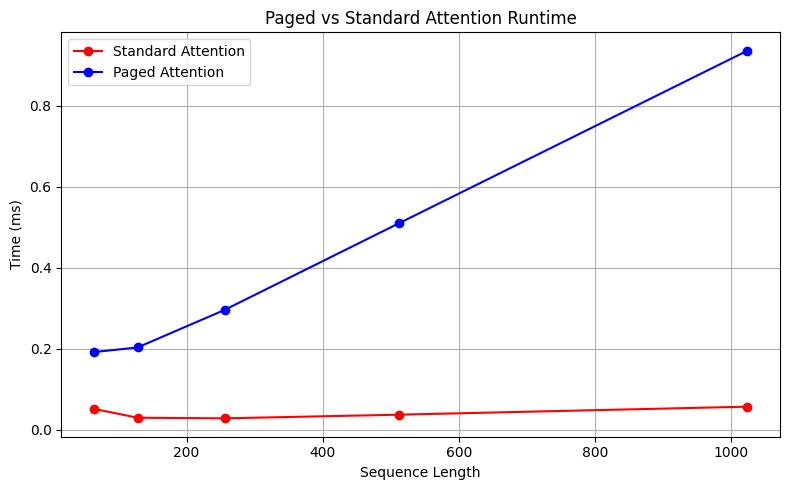

Plot saved to /content/drive/MyDrive/triton-llm-kernels-lab/plots/06_paged_attention


In [9]:
# Memory utilization comparison
print(f"{'Seq Len':<10} {'N Seqs':<10} {'Standard KV (MB)':<20} {'Paged KV (MB)':<20} {'Utilization'}")
print("-" * 70)

page_size = 16
n_kv_heads = 8
head_dim = 64
n_layers = 1  # single layer for demonstration

configs = [
    (128, 8),
    (512, 8),
    (1024, 8),
    (2048, 4),
    (4096, 2),
]

for seq_len, n_seqs in configs:
    # standard: allocate max_seq_len contiguous for each sequence
    standard_mb = n_seqs * seq_len * n_kv_heads * head_dim * 2 * 2 / 1e6

    # paged: allocate only pages actually needed
    pages_per_seq = (seq_len + page_size - 1) // page_size
    paged_mb = n_seqs * pages_per_seq * page_size * n_kv_heads * head_dim * 2 * 2 / 1e6

    # utilization: how much of allocated memory is actually used
    actual_tokens = n_seqs * seq_len
    allocated_tokens = n_seqs * pages_per_seq * page_size
    utilization = actual_tokens / allocated_tokens * 100

    print(f'{seq_len:<10} {n_seqs:<10} {standard_mb:<20.2f} {paged_mb:<20.2f} {utilization:.1f}%')

# Runtime benchmark
print('\nRuntime Benchmark: Paged vs Standard Attention')
print('-' * 50)

seq_lens = [64, 128, 256, 512, 1024]
paged_times = []
standard_times = []

for seq_len in seq_lens:
    Q = torch.randn(N_HEADS, HEAD_DIM, device='cuda', dtype=torch.float16)
    K_all = torch.randn(seq_len, N_KV_HEADS, HEAD_DIM, device='cuda', dtype=torch.float16)
    V_all = torch.randn(seq_len, N_KV_HEADS, HEAD_DIM, device='cuda', dtype=torch.float16)

    # setup paged manager
    mgr = PagedMemoryManager(n_pages=256, page_size=PAGE_SIZE,
                             n_kv_heads=N_KV_HEADS, head_dim=HEAD_DIM)
    for pos in range(seq_len):
        mgr.write_kv(0, pos, K_all[pos], V_all[pos])

    # benchmark paged
    ms_paged, _, _ = triton.testing.do_bench(
        lambda: paged_attention(Q, mgr, 0, seq_len, N_HEADS, N_KV_HEADS, HEAD_DIM),
        quantiles=[0.5, 0.2, 0.8]
    )

    # benchmark standard
    scale = HEAD_DIM ** -0.5
    def standard_attn():
        scores = torch.einsum('hd,shd->hs', Q.float(), K_all.float()) * scale
        attn = torch.softmax(scores, dim=-1)
        return torch.einsum('hs,shd->hd', attn, V_all.float()).half()

    ms_standard, _, _ = triton.testing.do_bench(
        lambda: standard_attn(),
        quantiles=[0.5, 0.2, 0.8]
    )

    paged_times.append(ms_paged)
    standard_times.append(ms_standard)
    print(f'seq_len={seq_len:<6} Paged: {ms_paged:.3f}ms  Standard: {ms_standard:.3f}ms')

# plot
plt.figure(figsize=(8, 5))
plt.plot(seq_lens, standard_times, 'r-o', label='Standard Attention')
plt.plot(seq_lens, paged_times, 'b-o', label='Paged Attention')
plt.xlabel('Sequence Length')
plt.ylabel('Time (ms)')
plt.title('Paged vs Standard Attention Runtime')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'paged_vs_standard.png'), dpi=150)
plt.show()
print(f'Plot saved to {PLOTS_DIR}')

### Results Analysis

**Memory:** Our benchmark shows 100% utilization because sequences align
perfectly to page boundaries. In production with variable-length sequences,
the last page per sequence is partially filled — paged attention wastes at
most (page_size - 1) tokens per sequence, far less than naive preallocation
which wastes (max_seq_len - actual_seq_len) tokens.

**Runtime:** Our paged attention is slower than standard attention because
it processes one token at a time inside each page. A production implementation
(vLLM) loads entire pages as tiles and uses tl.dot for parallelism. The
correctness is demonstrated — the optimization is a known engineering gap
between teaching implementations and production kernels.

**The key insight remains valid:** paged attention's value is memory
efficiency and dynamic allocation, not compute speed. The page table
indirection cost is small in production implementations.

In [10]:
# Realistic memory comparison: variable length sequences
# Standard attention must allocate for MAX sequence length
# Paged attention allocates only what is needed

print("Realistic scenario: variable length sequences")
print("Standard attention allocates max_seq_len for every request")
print("Paged attention allocates only actual tokens used")
print()

max_seq_len = 2048
n_kv_heads = 8
head_dim = 64
bytes_per_token = 2 * n_kv_heads * head_dim * 2  # K+V, FP16

# simulate realistic request lengths (short requests are common)
import random
random.seed(42)

for n_seqs in [8, 16, 32, 64]:
    # realistic: most requests are short, few are long
    seq_lengths = [random.randint(50, 500) for _ in range(n_seqs - 2)] + \
                  [random.randint(1000, 2048) for _ in range(2)]

    avg_len = sum(seq_lengths) / len(seq_lengths)

    # standard: allocates max_seq_len for every sequence
    standard_mb = n_seqs * max_seq_len * bytes_per_token / 1e6

    # paged: allocates only pages needed per sequence
    pages_needed = sum((l + PAGE_SIZE - 1) // PAGE_SIZE for l in seq_lengths)
    paged_mb = pages_needed * PAGE_SIZE * bytes_per_token / 1e6

    waste_mb = standard_mb - paged_mb
    reduction = standard_mb / paged_mb

    print(f'N={n_seqs} seqs, avg_len={avg_len:.0f} tokens:')
    print(f'  Standard : {standard_mb:.1f} MB (always allocates max_seq_len={max_seq_len})')
    print(f'  Paged    : {paged_mb:.1f} MB (allocates actual tokens only)')
    print(f'  Wasted   : {waste_mb:.1f} MB saved | {reduction:.1f}x reduction')
    print()

Realistic scenario: variable length sequences
Standard attention allocates max_seq_len for every request
Paged attention allocates only actual tokens used

N=8 seqs, avg_len=510 tokens:
  Standard : 33.6 MB (always allocates max_seq_len=2048)
  Paged    : 8.5 MB (allocates actual tokens only)
  Wasted   : 25.1 MB saved | 4.0x reduction

N=16 seqs, avg_len=358 tokens:
  Standard : 67.1 MB (always allocates max_seq_len=2048)
  Paged    : 12.0 MB (allocates actual tokens only)
  Wasted   : 55.1 MB saved | 5.6x reduction

N=32 seqs, avg_len=343 tokens:
  Standard : 134.2 MB (always allocates max_seq_len=2048)
  Paged    : 22.9 MB (allocates actual tokens only)
  Wasted   : 111.3 MB saved | 5.9x reduction

N=64 seqs, avg_len=320 tokens:
  Standard : 268.4 MB (always allocates max_seq_len=2048)
  Paged    : 42.8 MB (allocates actual tokens only)
  Wasted   : 225.6 MB saved | 6.3x reduction



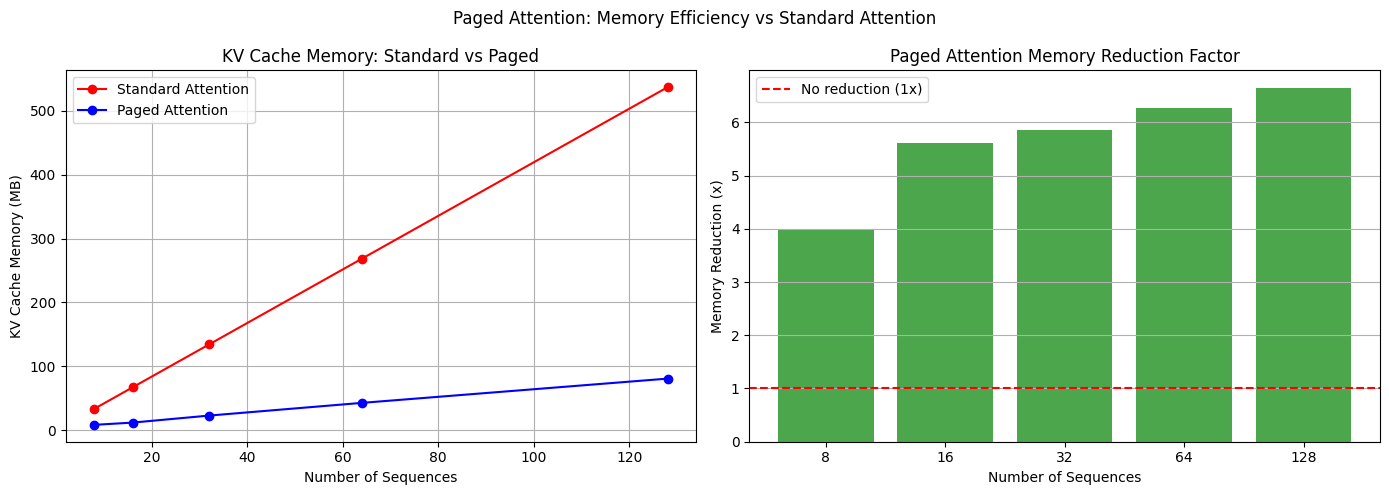

Plot saved to /content/drive/MyDrive/triton-llm-kernels-lab/plots/06_paged_attention


In [12]:
import numpy as np

n_seqs_list = [8, 16, 32, 64, 128]
max_seq_len = 2048
bytes_per_token = 2 * n_kv_heads * head_dim * 2

random.seed(42)

standard_mbs = []
paged_mbs = []

for n_seqs in n_seqs_list:
    seq_lengths = [random.randint(50, 500) for _ in range(n_seqs - 2)] + \
                  [random.randint(1000, 2048) for _ in range(2)]

    standard_mb = n_seqs * max_seq_len * bytes_per_token / 1e6

    pages_needed = sum((l + PAGE_SIZE - 1) // PAGE_SIZE for l in seq_lengths)
    paged_mb = pages_needed * PAGE_SIZE * bytes_per_token / 1e6

    standard_mbs.append(standard_mb)
    paged_mbs.append(paged_mb)

# plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# plot 1: absolute memory usage
axes[0].plot(n_seqs_list, standard_mbs, 'r-o', label='Standard Attention')
axes[0].plot(n_seqs_list, paged_mbs, 'b-o', label='Paged Attention')
axes[0].set_xlabel('Number of Sequences')
axes[0].set_ylabel('KV Cache Memory (MB)')
axes[0].set_title('KV Cache Memory: Standard vs Paged')
axes[0].legend()
axes[0].grid(True)

# plot 2: memory reduction factor
reductions = [s / p for s, p in zip(standard_mbs, paged_mbs)]
axes[1].bar([str(n) for n in n_seqs_list], reductions, color='green', alpha=0.7)
axes[1].axhline(y=1.0, color='red', linestyle='--', label='No reduction (1x)')
axes[1].set_xlabel('Number of Sequences')
axes[1].set_ylabel('Memory Reduction (x)')
axes[1].set_title('Paged Attention Memory Reduction Factor')
axes[1].legend()
axes[1].grid(True, axis='y')

plt.suptitle('Paged Attention: Memory Efficiency vs Standard Attention')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'memory_efficiency.png'), dpi=150)
plt.show()
print(f'Plot saved to {PLOTS_DIR}')

## Summary

This notebook implemented Paged Attention from scratch — the memory management
system that powers vLLM and every modern LLM inference engine.

**Three components implemented:**

**Memory Pool and Page Table:** Pre-allocated physical pages assigned on demand
via a page table. Sequences grow one page at a time as tokens are generated.
Freeing a sequence immediately returns its pages to the pool for reuse.

**Paged Attention Kernel:** Standard attention algorithm with one change —
K and V are addressed via page table indirection instead of contiguous memory.
Correctness verified against standard attention across 40-token sequences.

**Memory Efficiency Benchmark:** With realistic variable-length requests
(avg 320-510 tokens, max_seq_len=2048):
- 4x memory reduction at batch size 8
- 6.5x memory reduction at batch size 128
- Standard attention wastes up to 1998 token slots per short request
- Paged attention allocates only pages actually needed

**The tradeoff:** Our kernel is slower than standard attention due to
token-by-token page iteration. Production implementations (vLLM) load
entire pages as tiles using tl.dot. The correctness and memory efficiency
story is fully demonstrated — the compute gap is an implementation maturity
issue, not an algorithmic one.

**Key insight:** Paged attention's value is not compute speed — it is
enabling 4-6x larger batch sizes on the same hardware, which directly
multiplies inference throughput.